<a href="https://colab.research.google.com/github/farahwadya/Analysis-of-Crime-Trends-in-Chicago-2001-2022-/blob/main/Chicago_crime_time_series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# import packages

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter
import matplotlib.dates as mdates
import statsmodels.tsa.api as tsa
import os
!pip install pmdarima
import pmdarima as pm
from pmdarima.arima.utils import ndiffs, nsdiffs
from pmdarima.model_selection import train_test_split


# Set wide fig size for plots
plt.rcParams['figure.figsize']=(12,3)

In [38]:
!pip install holidays

In [39]:
import holidays
import datetime as dt
from holidays import country_holidays


In [40]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import statsmodels.tsa.api as tsa
def get_sig_lags(ts, type='ACF',  nlags=None,alpha=0.5):


    if type == 'ACF':
        # Running the function used by plot_acf
        corr_values, conf_int = tsa.stattools.acf(ts, alpha=alpha, nlags=nlags)

    elif type=='PACF':
        corr_values, conf_int = tsa.stattools.pacf(ts, alpha=alpha, nlags=nlags)

    else:
        raise Exception("type must be either 'ACF' or 'PACF'")

    # Determine lags
    lags =range(len(corr_values))

    # Create a centered version of the acf_df
    corr_df = pd.DataFrame({type:corr_values,
                            'Lags':lags,
                            'lower ci': conf_int[:,0]-corr_values, # subtract acf from lower ci to center
                            'upper ci': conf_int[:,1]-corr_values, # subtact acf to upper ci to center
                                 })
    corr_df = corr_df.set_index("Lags")

    # Getting filter for sig lags
    filter_sig_lags = (corr_df[type] < corr_df['lower ci']) | (corr_df[type] > corr_df['upper ci'])

    # Get lag #'s
    sig_lags= corr_df.index[filter_sig_lags]
    sig_lags = sig_lags[sig_lags!=0]

    return sig_lags
def plot_acf_pacf(ts, nlags=40, figsize=(10, 5),
                  annotate_sig=False, alpha=.05,
                 acf_kws={}, pacf_kws={},
                  annotate_seas=False, m = None,
                 seas_color='black'):

    fig, axes = plt.subplots(nrows=2, figsize=figsize)


    # Sig lags line style
    sig_vline_kwargs = dict( ls=':', lw=1, zorder=0, color='red')

    # ACF
    tsa.graphics.plot_acf(ts, ax=axes[0], lags=nlags, **acf_kws)

    ## Annotating sig acf lags
    if annotate_sig == True:
        sig_acf_lags = get_sig_lags(ts,nlags=nlags,alpha=alpha, type='ACF')
        for lag in sig_acf_lags:
            axes[0].axvline(lag,label='sig', **sig_vline_kwargs )

    # PACF
    tsa.graphics.plot_pacf(ts,ax=axes[1], lags=nlags, **pacf_kws)

    ## Annotating sig pacf lags
    if annotate_sig == True:
        ## ANNOTATING SIG LAGS
        sig_pacf_lags = get_sig_lags(ts,nlags=nlags,alpha=alpha, type='PACF')
        for lag in sig_pacf_lags:
            axes[1].axvline(lag, label='sig', **sig_vline_kwargs)




    ### ANNOTATE SEASONS
    if annotate_seas == True:
        # Ensure m was defined
        if m is None:
            raise Exception("Must define value of m if annotate_seas=True.")

        ## Calculate number of complete seasons to annotate
        n_seasons = nlags//m

        # Seasonal Lines style
        seas_vline_kwargs = dict( ls='--',lw=1, alpha=.7, color=seas_color, zorder=-1)

        ## for each season, add a line
        for i in range(1, n_seasons+1):
            axes[0].axvline(m*i, **seas_vline_kwargs, label="season")
            axes[1].axvline(m*i, **seas_vline_kwargs, label="season")

    fig.tight_layout()

    return fig

In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
def regression_metrics_ts(ts_true, ts_pred, label="", verbose=True, output_dict=False,):
    # Get metrics
    mae = mean_absolute_error(ts_true, ts_pred)
    mse = mean_squared_error(ts_true, ts_pred)
    rmse=np.sqrt(mse)
   # rmse = mean_squared_error(ts_true, ts_pred, squared=False)
    r_squared = r2_score(ts_true, ts_pred)
    mae_perc = mean_absolute_percentage_error(ts_true, ts_pred) * 100
    if verbose == True:
        # Print Result with label
        header = "---" * 20
        print(header, f"Regression Metrics: {label}", header, sep="\n")
        print(f"- MAE = {mae:,.3f}")
        print(f"- MSE = {mse:,.3f}")
        print(f"- RMSE = {rmse:,.3f}")
        print(f"- R^2 = {r_squared:,.3f}")
        print(f"- MAPE = {mae_perc:,.2f}%")
    if output_dict == True:
        metrics = {
            "Label": label,
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "R^2": r_squared,
            "MAPE(%)": mae_perc,
        }
        return metrics

In [42]:

# Custom function for Ad Fuller Test
def get_adfuller_results(ts, alpha=.05, label='adfuller', **kwargs): #kwargs for adfuller()
    # Saving each output
    (test_stat, pval, nlags, nobs, crit_vals_d,
    icbest ) = tsa.adfuller(ts, **kwargs)
    # Converting output to a dictionary with the interpretation of p
    adfuller_results = {'Test Statistic': test_stat,
                        "# of Lags Used":nlags,
                       '# of Observations':nobs,
                        'p-value': round(pval,6),
                        'alpha': alpha,
                       'sig/stationary?': pval < alpha}
    return pd.DataFrame(adfuller_results, index =[label])

In [43]:
def plot_forecast(ts_train, ts_test, forecast_df, n_train_lags=None,
                  figsize=(10,4), title='Comparing Forecast vs. True Data'):
    ### PLot training data, and forecast (with upper/,lower ci)
    fig, ax = plt.subplots(figsize=figsize)

    # setting the number of train lags to plot if not specified
    if n_train_lags==None:
        n_train_lags = len(ts_train)

    # Plotting Training  and test data
    ts_train.iloc[-n_train_lags:].plot(ax=ax, label="train")
    ts_test.plot(label="test", ax=ax)

    # Plot forecast
    forecast_df['mean'].plot(ax=ax, color='green', label="forecast")

    # Add the shaded confidence interval
    ax.fill_between(forecast_df.index,
                    forecast_df['mean_ci_lower'],
                   forecast_df['mean_ci_upper'],
                   color='green', alpha=0.3,  lw=2)

    # set the title and add legend
    ax.set_title(title)
    ax.legend();

    return fig, ax

# upload dataset

In [44]:
df2001=pd.read_csv('/content/drive/MyDrive/AXSOSACADEMY/06-AdvancedML/Week21/Data/Data/Chicago-Crime_2001.csv')
df2002=pd.read_csv('/content/drive/MyDrive/AXSOSACADEMY/06-AdvancedML/Week21/Data/Data/Chicago-Crime_2002.csv')
df2003=pd.read_csv('/content/drive/MyDrive/AXSOSACADEMY/06-AdvancedML/Week21/Data/Data/Chicago-Crime_2003.csv')
df2004=pd.read_csv('/content/drive/MyDrive/AXSOSACADEMY/06-AdvancedML/Week21/Data/Data/Chicago-Crime_2004.csv')
df2005=pd.read_csv('/content/drive/MyDrive/AXSOSACADEMY/06-AdvancedML/Week21/Data/Data/Chicago-Crime_2005.csv')
df2006=pd.read_csv('/content/drive/MyDrive/AXSOSACADEMY/06-AdvancedML/Week21/Data/Data/Chicago-Crime_2006.csv')
df2007=pd.read_csv('/content/drive/MyDrive/AXSOSACADEMY/06-AdvancedML/Week21/Data/Data/Chicago-Crime_2007.csv')
df2008=pd.read_csv('/content/drive/MyDrive/AXSOSACADEMY/06-AdvancedML/Week21/Data/Data/Chicago-Crime_2008.csv')
df2009=pd.read_csv('/content/drive/MyDrive/AXSOSACADEMY/06-AdvancedML/Week21/Data/Data/Chicago-Crime_2009.csv')
df2010=pd.read_csv('/content/drive/MyDrive/AXSOSACADEMY/06-AdvancedML/Week21/Data/Data/Chicago-Crime_2010.csv')
df2011=pd.read_csv('/content/drive/MyDrive/AXSOSACADEMY/06-AdvancedML/Week21/Data/Data/Chicago-Crime_2011.csv')
df2012=pd.read_csv('/content/drive/MyDrive/AXSOSACADEMY/06-AdvancedML/Week21/Data/Data/Chicago-Crime_2012.csv')
df2013=pd.read_csv('/content/drive/MyDrive/AXSOSACADEMY/06-AdvancedML/Week21/Data/Data/Chicago-Crime_2013.csv')
df2014=pd.read_csv('/content/drive/MyDrive/AXSOSACADEMY/06-AdvancedML/Week21/Data/Data/Chicago-Crime_2014.csv')
df2015=pd.read_csv('/content/drive/MyDrive/AXSOSACADEMY/06-AdvancedML/Week21/Data/Data/Chicago-Crime_2015.csv')
df2016=pd.read_csv('/content/drive/MyDrive/AXSOSACADEMY/06-AdvancedML/Week21/Data/Data/Chicago-Crime_2016.csv')
df2017=pd.read_csv('/content/drive/MyDrive/AXSOSACADEMY/06-AdvancedML/Week21/Data/Data/Chicago-Crime_2017.csv')
df2018=pd.read_csv('/content/drive/MyDrive/AXSOSACADEMY/06-AdvancedML/Week21/Data/Data/Chicago-Crime_2018.csv')
df2019=pd.read_csv('/content/drive/MyDrive/AXSOSACADEMY/06-AdvancedML/Week21/Data/Data/Chicago-Crime_2019.csv')
df2020=pd.read_csv('/content/drive/MyDrive/AXSOSACADEMY/06-AdvancedML/Week21/Data/Data/Chicago-Crime_2020.csv')
df2021=pd.read_csv('/content/drive/MyDrive/AXSOSACADEMY/06-AdvancedML/Week21/Data/Data/Chicago-Crime_2021.csv')
df2022=pd.read_csv('/content/drive/MyDrive/AXSOSACADEMY/06-AdvancedML/Week21/Data/Data/Chicago-Crime_2022.csv')

In [45]:
dfs = [
    df2001, df2002, df2003, df2004, df2005,
    df2006, df2007, df2008, df2009, df2010,
    df2011, df2012, df2013, df2014, df2015,
    df2016, df2017, df2018, df2019, df2020,
    df2021, df2022
]

df = pd.concat(dfs, ignore_index=True)

In [46]:
df.head()

,ID,Date,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude
0,1326041,01/01/2001 01:00:00 AM,BATTERY,SIMPLE,RESIDENCE,False,False,1624,16.0,NaN,41.957850,-87.749185
1,1319931,01/01/2001 01:00:00 PM,BATTERY,SIMPLE,RESIDENCE,False,True,825,8.0,NaN,41.783892,-87.684841
2,1324743,01/01/2001 01:00:00 PM,GAMBLING,ILLEGAL ILL LOTTERY,STREET,True,False,313,3.0,NaN,41.780412,-87.611970
3,1310717,01/01/2001 01:00:00 AM,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,2424,24.0,NaN,42.012391,-87.678032
4,1318099,01/01/2001 01:00:00 AM,BATTERY,SIMPLE,RESIDENCE PORCH/HALLWAY,False,True,214,2.0,NaN,41.819538,-87.620020


In [47]:
df.shape

(7713109, 12)

In [48]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

In [49]:
df.head()

,ID,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude
Date,,,,,,,,,,,
2001-01-01 01:00:00,1326041,BATTERY,SIMPLE,RESIDENCE,False,False,1624,16.0,NaN,41.957850,-87.749185
2001-01-01 13:00:00,1319931,BATTERY,SIMPLE,RESIDENCE,False,True,825,8.0,NaN,41.783892,-87.684841
2001-01-01 13:00:00,1324743,GAMBLING,ILLEGAL ILL LOTTERY,STREET,True,False,313,3.0,NaN,41.780412,-87.611970
2001-01-01 01:00:00,1310717,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,2424,24.0,NaN,42.012391,-87.678032
2001-01-01 01:00:00,1318099,BATTERY,SIMPLE,RESIDENCE PORCH/HALLWAY,False,True,214,2.0,NaN,41.819538,-87.620020


In [50]:
daily_crime=df.resample('D').size().to_frame(name='count').reset_index()
daily_crime


,Date,count
0,2001-01-01,1825
1,2001-01-02,1143
2,2001-01-03,1151
3,2001-01-04,1166
4,2001-01-05,1267
...,...,...
8030,2022-12-27,583
8031,2022-12-28,618
8032,2022-12-29,648
8033,2022-12-30,674


In [51]:
us_holiday=country_holidays('US')
us_holiday

holidays.country_holidays('US')

In [52]:
all_days=pd.date_range(df.index.min(),df.index.max())
for i in all_days:
  if i in us_holiday:
   print({i})

{Timestamp('2001-01-01 00:00:00')}
{Timestamp('2001-01-15 00:00:00')}
{Timestamp('2001-02-19 00:00:00')}
{Timestamp('2001-05-28 00:00:00')}
{Timestamp('2001-07-04 00:00:00')}
{Timestamp('2001-09-03 00:00:00')}
{Timestamp('2001-10-08 00:00:00')}
{Timestamp('2001-11-11 00:00:00')}
{Timestamp('2001-11-12 00:00:00')}
{Timestamp('2001-11-22 00:00:00')}
{Timestamp('2001-12-25 00:00:00')}
{Timestamp('2002-01-01 00:00:00')}
{Timestamp('2002-01-21 00:00:00')}
{Timestamp('2002-02-18 00:00:00')}
{Timestamp('2002-05-27 00:00:00')}
{Timestamp('2002-07-04 00:00:00')}
{Timestamp('2002-09-02 00:00:00')}
{Timestamp('2002-10-14 00:00:00')}
{Timestamp('2002-11-11 00:00:00')}
{Timestamp('2002-11-28 00:00:00')}
{Timestamp('2002-12-25 00:00:00')}
{Timestamp('2003-01-01 00:00:00')}
{Timestamp('2003-01-20 00:00:00')}
{Timestamp('2003-02-17 00:00:00')}
{Timestamp('2003-05-26 00:00:00')}
{Timestamp('2003-07-04 00:00:00')}
{Timestamp('2003-09-01 00:00:00')}
{Timestamp('2003-10-13 00:00:00')}
{Timestamp('2003-11-

# Topic 2) Crimes Across the Years:

- Is the total number of crimes increasing or decreasing across the years?
- Are there any individual crimes that are doing the opposite (e.g., decreasing when overall crime is increasing or vice-versa)?

In [53]:
# we need to obtain the total number of crimes by using .size()
df['Year']=df.index.year
crime_per_year=df.groupby('Year').size()
crime_per_year.index = pd.to_datetime(crime_per_year.index, format='%Y')
print(crime_per_year)

Year
2001-01-01    485886
2002-01-01    486807
2003-01-01    475985
2004-01-01    469422
2005-01-01    453773
2006-01-01    448179
2007-01-01    437087
2008-01-01    427183
2009-01-01    392827
2010-01-01    370513
2011-01-01    351993
2012-01-01    336319
2013-01-01    307536
2014-01-01    275789
2015-01-01    264787
2016-01-01    269823
2017-01-01    269100
2018-01-01    268899
2019-01-01    261325
2020-01-01    212194
2021-01-01    208824
2022-01-01    238858
dtype: int64


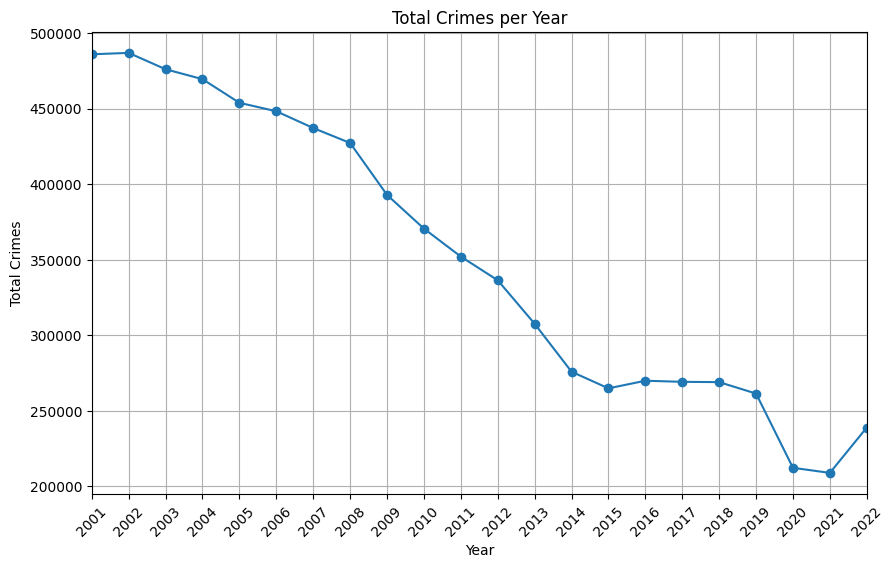

In [54]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,6))
crime_per_year.plot(marker='o', ax=ax)

ax.set_title('Total Crimes per Year')
ax.set_xlabel('Year')
ax.set_ylabel('Total Crimes')

ax.set_xticks(crime_per_year.index)
ax.set_xticklabels(crime_per_year.index.year, rotation=45)

plt.grid(True)
plt.show()


"The total number of crimes in Chicago has been decreasing over the years, with the lowest number recorded in 2015. This indicates a general decline in crime across the city during this period."

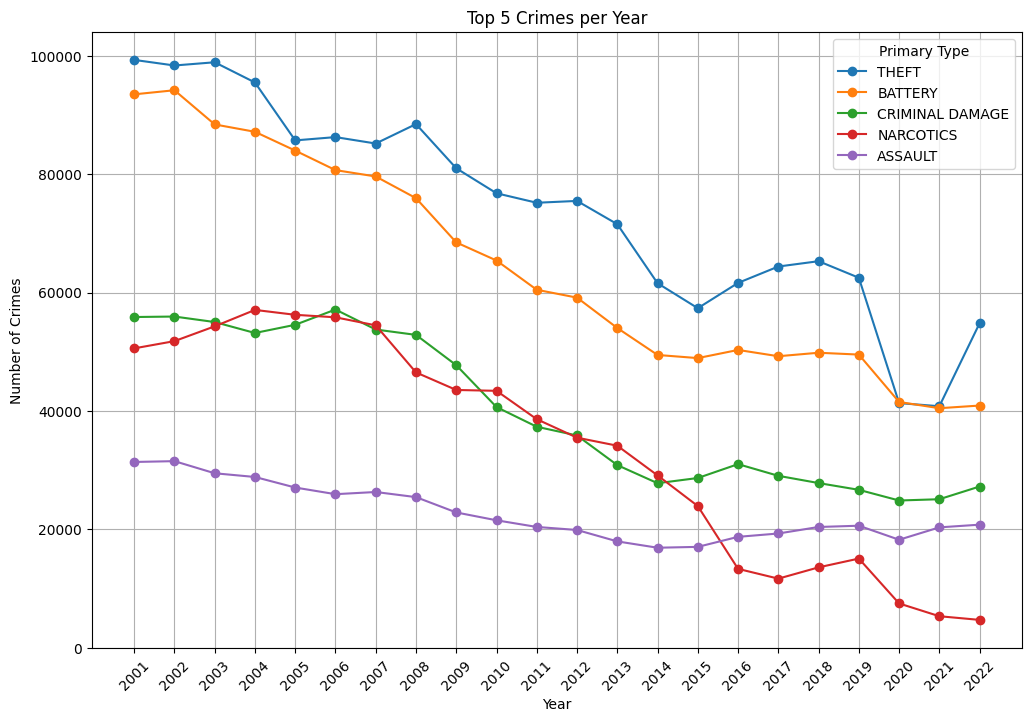

In [55]:
import matplotlib.pyplot as plt
type_per_year = df.groupby(['Year', 'Primary Type']).size().unstack(fill_value=0)
top_crime = type_per_year.sum().sort_values(ascending=False).head(5).index

# Plot the top 5 crimes over the years
ax = type_per_year[top_crime].plot(figsize=(12,8), marker='o')

# Set axis labels and title
ax.set_xlabel('Year')
ax.set_ylabel('Number of Crimes')
ax.set_title('Top 5 Crimes per Year')

# Fix the X-axis to show exact years without decimals
ax.set_xticks(type_per_year.index)                     # Set tick positions at each year
ax.set_xticklabels(type_per_year.index, rotation=45)   # Label each tick with the year, rotated for readability

plt.grid(True)
plt.show()


In [56]:
start_year = 2001
end_year = 2022

# calculating diff for each crime
total_change = type_per_year.loc[end_year] - type_per_year.loc[start_year]

# sorting crimes
total_change_sorted = total_change.sort_values()

print(total_change_sorted)


Primary Type
BATTERY                             -52550
NARCOTICS                           -45850
THEFT                               -44457
CRIMINAL DAMAGE                     -28618
BURGLARY                            -18422
OTHER OFFENSE                       -15104
ASSAULT                             -10588
ROBBERY                              -9476
CRIMINAL TRESPASS                    -9016
MOTOR VEHICLE THEFT                  -6104
PROSTITUTION                         -5743
PUBLIC PEACE VIOLATION               -2040
CRIM SEXUAL ASSAULT                  -1779
LIQUOR LAW VIOLATION                 -1434
SEX OFFENSE                          -1014
GAMBLING                              -925
KIDNAPPING                            -816
ARSON                                 -590
OFFENSE INVOLVING CHILDREN            -384
INTIMIDATION                           -95
INTERFERENCE WITH PUBLIC OFFICER       -14
RITUALISM                               -8
PUBLIC INDECENCY                        -

Based on the analysis of crime trends from 2001 to 2018, the overall number of crimes in Chicago has been decreasing.

When we examine individual crime types, almost all major crimes show a significant decrease over the years:

BATTERY: -43,633 cases

NARCOTICS: -36,977 cases

THEFT: -33,991 cases

CRIMINAL DAMAGE: -28,036 cases

MOTOR VEHICLE THEFT: -17,568 cases

BURGLARY: -14,267 cases

OTHER OFFENSE: -12,398 cases

ASSAULT: -10,978 cases

ROBBERY: -8,760 cases

CRIMINAL TRESPASS: -6,332 cases

Only a few less frequent crime types show a slight increase:

WEAPONS VIOLATION: +1,179 cases

DECEPTIVE PRACTICE: +4,884 cases

CRIMINAL SEXUAL ASSAULT: +293 cases

OFFENSE INVOLVING CHILDREN: +156 cases

Therefore, most crimes follow the overall decreasing trend, and only a small number of less common offenses behave differently.

In [57]:
narcotics_per_year = type_per_year['NARCOTICS']
diff = narcotics_per_year.diff()
print(diff)

# الفرق بالنسبة المئوية
pct_change = narcotics_per_year.pct_change() * 100
print(pct_change)

total_drop = narcotics_per_year.loc[2001] - narcotics_per_year.loc[2018]
print(f"Total decrease from 2001 to 2018: {total_drop}")


Year
2001        NaN
2002     1222.0
2003     2499.0
2004     2772.0
2005     -826.0
2006     -421.0
2007    -1359.0
2008    -7948.0
2009    -2964.0
2010     -144.0
2011    -4793.0
2012    -3116.0
2013    -1360.0
2014    -5011.0
2015    -5179.0
2016   -10606.0
2017    -1650.0
2018     1907.0
2019     1482.0
2020    -7580.0
2021    -2155.0
2022     -620.0
Name: NARCOTICS, dtype: float64
Year
2001          NaN
2002     2.416596
2003     4.825349
2004     5.106101
2005    -1.447599
2006    -0.748657
2007    -2.434917
2008   -14.595806
2009    -6.373371
2010    -0.330715
2011   -11.044288
2012    -8.071493
2013    -3.832173
2014   -14.682528
2015   -17.786249
2016   -44.304273
2017   -12.375309
2018    16.322862
2019    10.905077
2020   -50.291932
2021   -28.764015
2022   -11.617013
Name: NARCOTICS, dtype: float64
Total decrease from 2001 to 2018: 36977


#Topic 1) Comparing Police Districts
- Which district had the most crimes in 2022?
- Which had the least?

In [58]:
df.head()

,ID,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude,Year
Date,,,,,,,,,,,,
2001-01-01 01:00:00,1326041,BATTERY,SIMPLE,RESIDENCE,False,False,1624,16.0,NaN,41.957850,-87.749185,2001
2001-01-01 13:00:00,1319931,BATTERY,SIMPLE,RESIDENCE,False,True,825,8.0,NaN,41.783892,-87.684841,2001
2001-01-01 13:00:00,1324743,GAMBLING,ILLEGAL ILL LOTTERY,STREET,True,False,313,3.0,NaN,41.780412,-87.611970,2001
2001-01-01 01:00:00,1310717,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,2424,24.0,NaN,42.012391,-87.678032,2001
2001-01-01 01:00:00,1318099,BATTERY,SIMPLE,RESIDENCE PORCH/HALLWAY,False,True,214,2.0,NaN,41.819538,-87.620020,2001


In [59]:
t2022=df[df.index.year==2022].reset_index()

print(df.index.max())


2022-12-31 23:55:00


In [60]:
t2022.head()

,Date,ID,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude,Year
0,2022-01-01 13:00:00,12582293,THEFT,$500 AND UNDER,RESTAURANT,False,False,121,1.0,42.0,41.881884,-87.640060,2022
1,2022-01-01 13:00:00,12607313,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT $300 AND UNDER,BANK,False,False,811,8.0,23.0,41.787923,-87.769446,2022
2,2022-01-01 01:00:00,12585671,CRIMINAL DAMAGE,TO VEHICLE,PARKING LOT / GARAGE (NON RESIDENTIAL),False,False,531,5.0,9.0,41.687443,-87.604120,2022
3,2022-01-01 01:00:00,12592889,OTHER OFFENSE,HARASSMENT BY TELEPHONE,APARTMENT,False,False,412,4.0,8.0,41.734353,-87.585147,2022
4,2022-01-01 01:00:00,12584977,THEFT,$500 AND UNDER,OTHER (SPECIFY),False,False,1811,18.0,2.0,41.910818,-87.654560,2022


In [61]:
district_crime=t2022.groupby('District').size()
district_crime

,0
District,
1.0,13044
2.0,11793
3.0,11937
4.0,13931
5.0,9773
6.0,14694
7.0,10319
8.0,14805
9.0,10376


In [62]:
max_crime=district_crime.idxmax()
min_crime=district_crime.idxmin()
print(f'max number of crime was at district {max_crime}')
print(f'max number of crime was at district {min_crime}')

max number of crime was at district 8.0
max number of crime was at district 31.0


#Topic 4) Comparing Months:
Answer the question: What months have the most crime? What months have the least?
Answer the question: Are there any individual crimes that do not follow this pattern? If so, which crimes?

In [63]:
df['month']=df.index.month
df['month']

,month
Date,
2001-01-01 01:00:00,1
2001-01-01 13:00:00,1
2001-01-01 13:00:00,1
2001-01-01 01:00:00,1
2001-01-01 01:00:00,1
...,...
2022-12-31 12:50:00,12
2022-12-31 12:50:00,12
2022-12-31 00:52:00,12


In [64]:
month_crime=df.groupby('month').size()
month_crime

,0
month,
1,601236
2,529391
3,629704
4,627175
5,682932
6,681739
7,717232
8,710444
9,668242


In [65]:
max_crime=month_crime.idxmax()
min_crime=month_crime.idxmin()
print(f'max number of crime happened in month {max_crime}')
print(f'min number of crime happened in month {min_crime}')

max number of crime happened in month 7
min number of crime happened in month 2


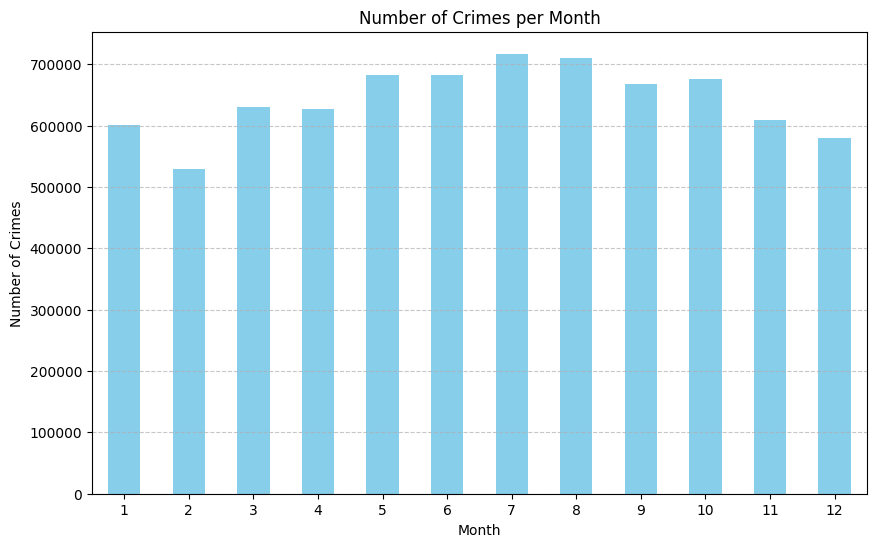

In [66]:

# Plotting monthly crime counts
plt.figure(figsize=(10,6))
month_crime.plot(kind='bar', color='skyblue')  # bar plot
plt.title('Number of Crimes per Month')
plt.xlabel('Month')
plt.ylabel('Number of Crimes')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [67]:
df.head(0)

,ID,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude,Year,month
Date,,,,,,,,,,,,,


In [68]:
crime_per_month=df.groupby(['Primary Type','month']).size().unstack(fill_value=0)
crime_per_month

month,1,2,3,4,5,6,7,8,9,10,11,12
Primary Type,,,,,,,,,,,,
ARSON,917,807,1111,1097,1230,1236,1350,1182,1131,1118,1019,923
ASSAULT,34818,33416,41709,42031,48453,47255,47900,46455,45427,42925,36390,34324
BATTERY,101302,93601,117869,118500,135678,135905,136817,128734,122346,118812,102961,98364
BURGLARY,32639,25652,30073,31372,36066,35958,39279,40597,38388,39550,37037,35635
CONCEALED CARRY LICENSE VIOLATION,62,69,77,78,96,92,95,96,118,99,73,64
CRIM SEXUAL ASSAULT,2575,1896,2112,2134,2404,2512,2676,2596,2449,2336,2043,1851
CRIMINAL DAMAGE,62574,55428,71873,75104,79685,78921,83397,81708,75468,80061,71565,63130
CRIMINAL SEXUAL ASSAULT,539,435,504,438,538,592,604,586,560,583,498,476
CRIMINAL TRESPASS,18471,16679,18734,17737,18379,17492,18029,18564,17914,18330,16736,15804


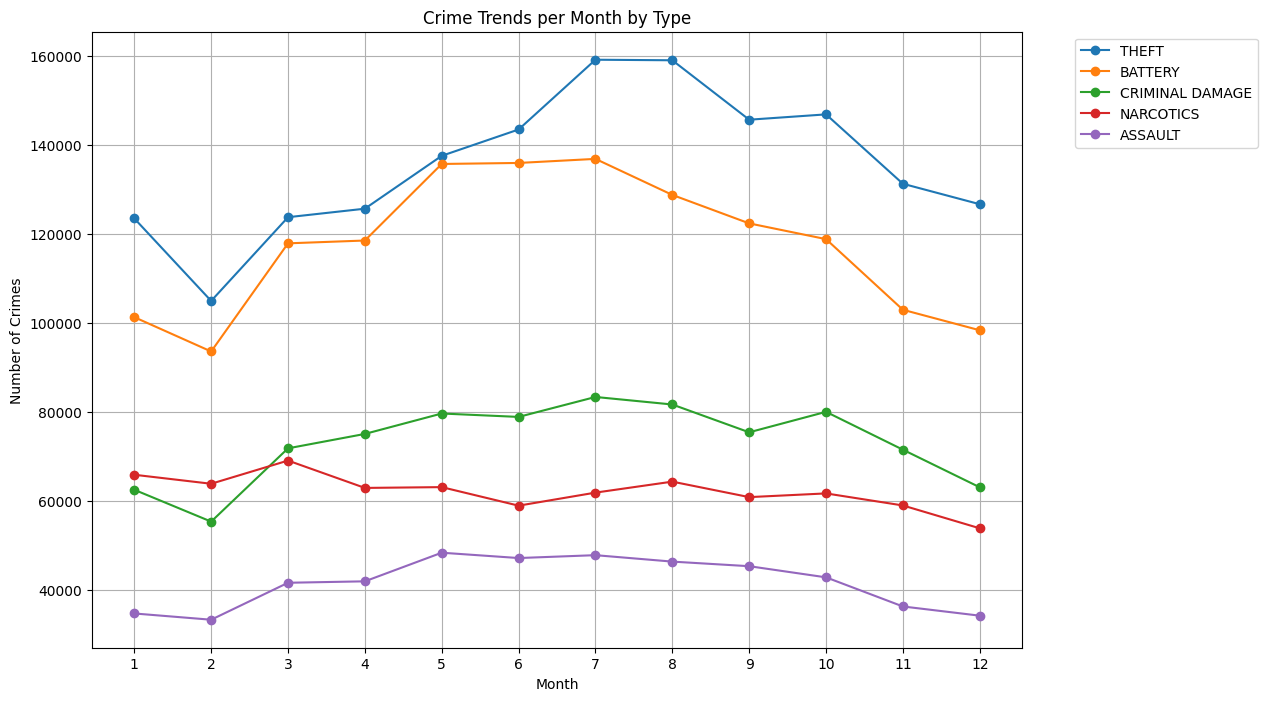

In [69]:
plt.figure(figsize=(12,8))
top_crime = type_per_year.sum().sort_values(ascending=False).head(5).index
for crime in top_crime:
    plt.plot(crime_per_month.columns, crime_per_month.loc[crime], marker='o', label=crime)

plt.title('Crime Trends per Month by Type')
plt.xlabel('Month')
plt.ylabel('Number of Crimes')
plt.xticks(range(1,13))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()


# Modeling

In [70]:
df.head()

,ID,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude,Year,month
Date,,,,,,,,,,,,,
2001-01-01 01:00:00,1326041,BATTERY,SIMPLE,RESIDENCE,False,False,1624,16.0,NaN,41.957850,-87.749185,2001,1
2001-01-01 13:00:00,1319931,BATTERY,SIMPLE,RESIDENCE,False,True,825,8.0,NaN,41.783892,-87.684841,2001,1
2001-01-01 13:00:00,1324743,GAMBLING,ILLEGAL ILL LOTTERY,STREET,True,False,313,3.0,NaN,41.780412,-87.611970,2001,1
2001-01-01 01:00:00,1310717,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,2424,24.0,NaN,42.012391,-87.678032,2001,1
2001-01-01 01:00:00,1318099,BATTERY,SIMPLE,RESIDENCE PORCH/HALLWAY,False,True,214,2.0,NaN,41.819538,-87.620020,2001,1


#

In [71]:
ts_Theft= df[df['Primary Type']=='THEFT']
ts_Theft.head()


,ID,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude,Year,month
Date,,,,,,,,,,,,,
2001-01-01 01:00:00,1310586,THEFT,$500 AND UNDER,STREET,False,False,911,9.0,NaN,41.798298,-87.692856,2001,1
2001-01-01 01:00:00,1315458,THEFT,$500 AND UNDER,STREET,False,False,1421,14.0,NaN,41.910320,-87.702020,2001,1
2001-01-01 13:00:00,6808288,THEFT,FINANCIAL ID THEFT: OVER $300,APARTMENT,False,False,213,2.0,3.0,41.822551,-87.615632,2001,1
2001-01-01 13:00:00,3769790,THEFT,AGG: FINANCIAL ID THEFT,RESIDENCE,False,False,523,5.0,34.0,41.673171,-87.638000,2001,1
2001-01-01 13:00:00,1316324,THEFT,OVER $500,STREET,False,False,1513,15.0,NaN,41.869008,-87.773947,2001,1


In [76]:
import datetime as dt
theft_mon=ts_Theft['Primary Type'].resample('M').count()
theft_mon

/tmp/ipykernel_490/1876649678.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  theft_mon=ts_Theft['Primary Type'].resample('M').count()


,Primary Type
Date,
2001-01-31,7867
2001-02-28,6669
2001-03-31,7766
2001-04-30,7702
2001-05-31,8420
...,...
2022-08-31,5244
2022-09-30,5117
2022-10-31,5242


<Axes: xlabel='Date'>

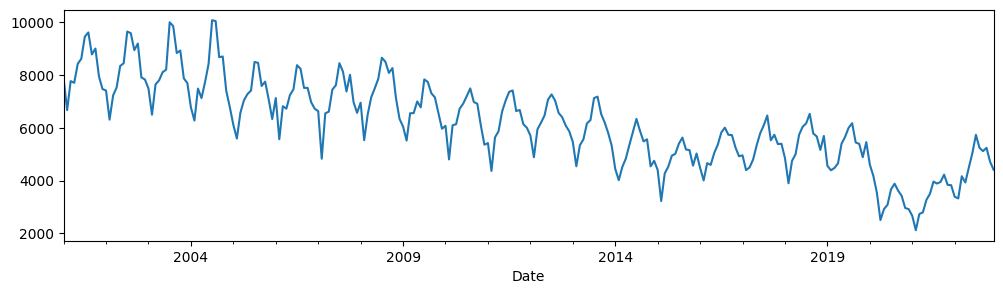

In [78]:
theft_mon.plot()

In [80]:
theft_mon.isnull().sum()

np.int64(0)